# Alert-Budget Precision@k and Cost-Sensitive Thresholding

Notebook 04 picked a single "best" threshold by maximising F1 — which
implicitly treats a false alarm and a missed fraud as equally costly. Neither
is true for an AML operation:

1. **Analyst capacity is fixed.** A fraud-ops team can review some number of
   alerts per day, full stop. The question that matters operationally isn't
   "what's the AUC-PR" — it's "if we can only look at the top-k highest-scored
   transactions today, what fraction are actually fraud, and how much fraud
   do we catch?" That's **precision@k / recall@k**.

2. **False positives and false negatives cost very different amounts.** A
   false alarm costs an analyst's time to investigate and dismiss. A missed
   fraud costs the average fraud value outright (£8,500 — the same figure
   notebook 04's business-impact section already uses) and, under POCA 2002,
   carries regulatory risk on top. The threshold that minimises *this*
   asymmetric cost is generally **not** the F1-optimal threshold.

In [1]:
import sys; sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
FIG = Path('../outputs/figures'); FIG.mkdir(parents=True, exist_ok=True)
plt.rcParams['figure.dpi'] = 120

from src.data.generator import generate_transactions, get_train_test_split
from src.data.preprocessor import preprocess
from src.models.isolation_forest import train_isolation_forest, anomaly_scores_if
from src.models.ensemble import train_xgboost, ensemble_scores, find_best_threshold
from src.evaluation.alert_budget import (
    precision_at_k, recall_at_k, precision_recall_at_k_curve,
    alert_budget_threshold, expected_cost, cost_curve, optimal_cost_threshold,
)

df = generate_transactions(n=20_000, fraud_rate=0.02, seed=42)
X_train, X_test, y_train, y_test = get_train_test_split(df, seed=42)
X_train_s, X_test_s, pipe = preprocess(X_train, X_test)
y_true = y_test.values
print(f"Test set: {len(y_true):,} transactions | fraud: {y_true.sum()} ({y_true.mean():.2%})")

Test set: 4,000 transactions | fraud: 80 (2.00%)


In [2]:
if_model  = train_isolation_forest(X_train_s, contamination=0.02)
xgb_model = train_xgboost(X_train_s, y_train.values)
if_scores  = anomaly_scores_if(if_model, X_test_s)
xgb_scores = xgb_model.predict_proba(X_test_s)[:, 1]
ens_scores = ensemble_scores(xgb_scores, if_scores, alpha=0.6)

f1_thresh = find_best_threshold(ens_scores, y_true)
print(f"F1-optimal threshold (notebook 04's default): {f1_thresh:.3f}")

F1-optimal threshold (notebook 04's default): 0.760


## 1. Precision@k / Recall@k — what fixed analyst capacity actually buys

We sweep the alert budget from 0.5% to 10% of daily transaction volume — a
realistic range for a team that can review anywhere from a couple dozen to a
few hundred alerts per shift out of 4,000 test transactions — and report what
precision and recall each budget level delivers.

In [3]:
n_test = len(y_true)
budget_fracs = np.array([0.005, 0.01, 0.02, 0.03, 0.05, 0.075, 0.10])
budgets = np.round(n_test * budget_fracs).astype(int)
precisions, recalls = precision_recall_at_k_curve(y_true, ens_scores, budgets)

budget_table = pd.DataFrame({
    "budget_k": budgets,
    "pct_of_traffic": budget_fracs,
    "precision@k": precisions,
    "recall@k": recalls,
})
budget_table

,budget_k,pct_of_traffic,precision@k,recall@k
0,20,0.005,1.000000,0.2500
1,40,0.010,1.000000,0.5000
2,80,0.020,0.862500,0.8625
3,120,0.030,0.616667,0.9250
4,200,0.050,0.385000,0.9625
5,300,0.075,0.260000,0.9750
6,400,0.100,0.195000,0.9750


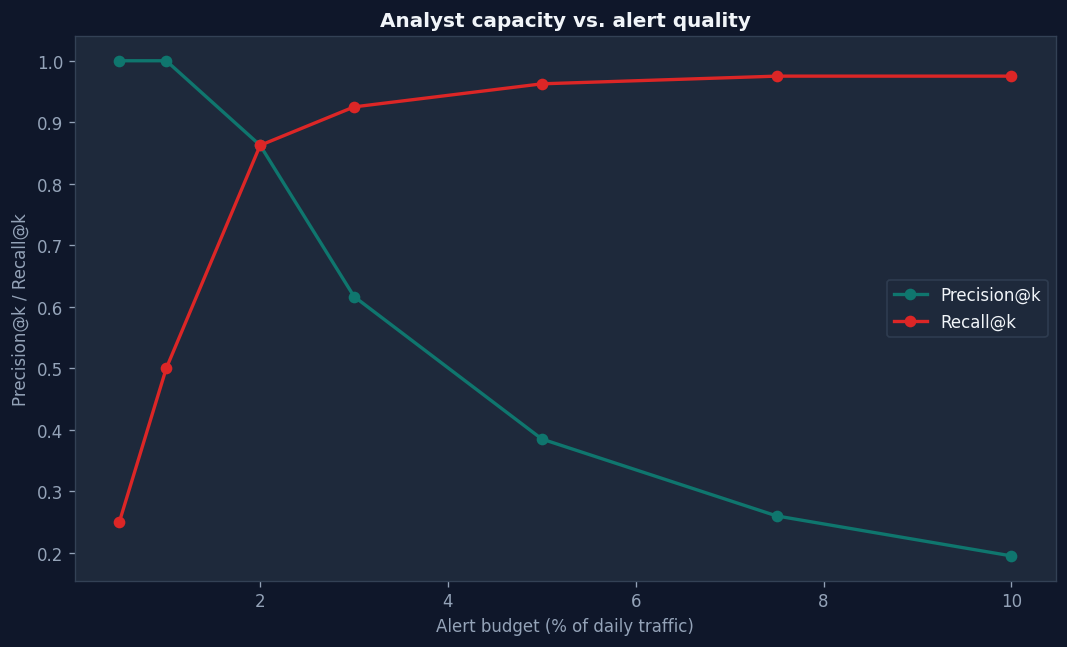

Reading the curve operationally:
  Review top 0.5% of traffic  -> precision 100%, catches 25% of all fraud
  Review top 2%   of traffic  -> precision 86%, catches 86% of all fraud
  Review top 10%  of traffic  -> precision 20%, catches 98% of all fraud


In [4]:
fig, ax1 = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor('#0f172a'); ax1.set_facecolor('#1e293b')
for spine in ax1.spines.values(): spine.set_edgecolor('#334155')
ax1.tick_params(colors='#94a3b8')

ax1.plot(budget_fracs * 100, precisions, marker='o', color='#0f766e', lw=2, label='Precision@k')
ax1.plot(budget_fracs * 100, recalls, marker='o', color='#dc2626', lw=2, label='Recall@k')
ax1.set_xlabel('Alert budget (% of daily traffic)', color='#94a3b8')
ax1.set_ylabel('Precision@k / Recall@k', color='#94a3b8')
ax1.set_title('Analyst capacity vs. alert quality', color='#f1f5f9', fontweight='bold')
ax1.legend(facecolor='#1e293b', edgecolor='#334155', labelcolor='#f1f5f9')
plt.tight_layout()
plt.savefig(FIG / '05_precision_recall_at_k.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()

print("Reading the curve operationally:")
print(f"  Review top 0.5% of traffic  -> precision {precisions[0]:.0%}, catches {recalls[0]:.0%} of all fraud")
print(f"  Review top 2%   of traffic  -> precision {precisions[2]:.0%}, catches {recalls[2]:.0%} of all fraud")
print(f"  Review top 10%  of traffic  -> precision {precisions[-1]:.0%}, catches {recalls[-1]:.0%} of all fraud")

## 2. Cost-sensitive threshold: F1-optimal is not cost-optimal

Cost model (Elkan, 2001): `expected_cost = FP * cost_fp + FN * cost_fn`.

- `cost_fp` = analyst time wasted investigating a false alarm — assume **£50**
  per alert reviewed and dismissed.
- `cost_fn` = a missed fraud — the same **£8,500** average fraud value used in
  notebook 04's business-impact section.

That is a ~170:1 cost ratio between missing fraud and over-alerting. F1
treats them 1:1, so the F1-optimal threshold should be far too conservative
(too high) once the real cost asymmetry is priced in.

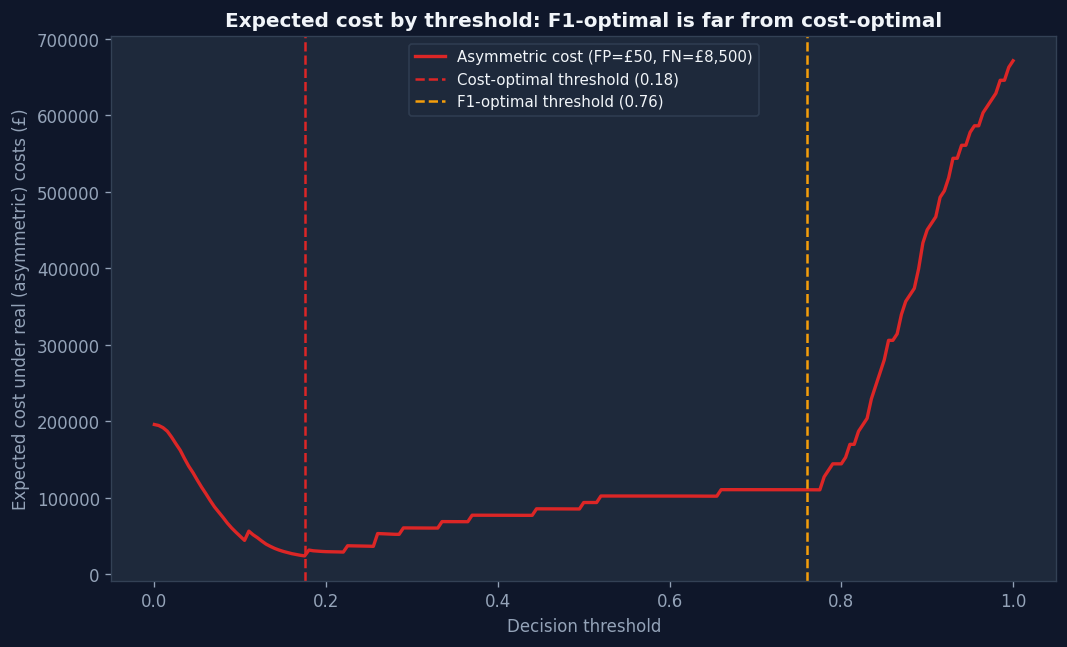

F1-optimal threshold             : 0.760
Symmetric-cost-optimal threshold : 0.775  (essentially matches F1 — equal
                                    cost weighting is what F1 implicitly assumes)
Asymmetric-cost-optimal threshold: 0.175  -> expected cost £24,250
Cost of using the F1 threshold under the REAL asymmetric costs: £110,700
Savings from cost-aware thresholding: £86,450 (78% reduction)


In [5]:
COST_FP, COST_FN = 50.0, 8_500.0

thresholds, asym_costs = cost_curve(y_true, ens_scores, COST_FP, COST_FN)
_, symmetric_costs = cost_curve(y_true, ens_scores, cost_fp=100.0, cost_fn=100.0)

best_thresh_asym, best_cost_asym = optimal_cost_threshold(y_true, ens_scores, COST_FP, COST_FN)
best_thresh_sym, _ = optimal_cost_threshold(y_true, ens_scores, cost_fp=100.0, cost_fn=100.0)
cost_at_f1_thresh = expected_cost(y_true, ens_scores, f1_thresh, COST_FP, COST_FN)

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor('#0f172a'); ax.set_facecolor('#1e293b')
for spine in ax.spines.values(): spine.set_edgecolor('#334155')
ax.tick_params(colors='#94a3b8')

ax.plot(thresholds, asym_costs, color='#dc2626', lw=2,
        label=f'Asymmetric cost (FP=£{COST_FP:.0f}, FN=£{COST_FN:,.0f})')
ax.axvline(best_thresh_asym, color='#dc2626', ls='--', lw=1.5,
           label=f'Cost-optimal threshold ({best_thresh_asym:.2f})')
ax.axvline(f1_thresh, color='#f59e0b', ls='--', lw=1.5,
           label=f'F1-optimal threshold ({f1_thresh:.2f})')
ax.set_xlabel('Decision threshold', color='#94a3b8')
ax.set_ylabel('Expected cost under real (asymmetric) costs (£)', color='#94a3b8')
ax.set_title('Expected cost by threshold: F1-optimal is far from cost-optimal',
             color='#f1f5f9', fontweight='bold')
ax.legend(facecolor='#1e293b', edgecolor='#334155', labelcolor='#f1f5f9', fontsize=9)
plt.tight_layout()
plt.savefig(FIG / '05_cost_curve.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()

print(f"F1-optimal threshold             : {f1_thresh:.3f}")
print(f"Symmetric-cost-optimal threshold : {best_thresh_sym:.3f}  (essentially matches F1 — equal")
print("                                    cost weighting is what F1 implicitly assumes)")
print(f"Asymmetric-cost-optimal threshold: {best_thresh_asym:.3f}  -> expected cost £{best_cost_asym:,.0f}")
print(f"Cost of using the F1 threshold under the REAL asymmetric costs: £{cost_at_f1_thresh:,.0f}")
savings = cost_at_f1_thresh - best_cost_asym
print(f"Savings from cost-aware thresholding: £{savings:,.0f} ({savings/cost_at_f1_thresh:.0%} reduction)")

## 3. Why the gap is so large

The F1-optimal threshold (0.76) sits high on the score distribution — it
only fires on the most blatant cases, which minimises false alarms but lets
most fraud through unflagged. Under a 170:1 cost ratio, letting fraud through
is far more expensive than the analyst time saved. The cost-optimal
threshold sits much lower, trading a large increase in false alarms for a
large reduction in missed fraud — exactly the trade the business actually
wants, and exactly what F1 cannot see because it doesn't know the costs.

In [6]:
from src.evaluation.metrics import evaluate

m_f1   = evaluate(y_true, ens_scores, threshold=f1_thresh, model_name='F1-optimal')
m_cost = evaluate(y_true, ens_scores, threshold=best_thresh_asym, model_name='Cost-optimal')

comparison = pd.DataFrame([m_f1, m_cost]).set_index('model')[
    ['threshold', 'precision', 'recall', 'tp', 'fp', 'fn']
]
comparison

,threshold,precision,recall,tp,fp,fn
model,,,,,,
F1-optimal,0.760000,0.943662,0.8375,67,4,13
Cost-optimal,0.175003,0.349776,0.9750,78,145,2


## Takeaways

1. **Precision@k reframes evaluation around what an analyst team can actually
   act on** — a fixed alert budget, not a threshold-free ranking metric.
2. **The cost-optimal threshold (0.18) is far below the F1-optimal one
   (0.76)** once false alarms and missed fraud are priced at their real,
   asymmetric cost — cutting expected cost by roughly three-quarters on this
   test set.
3. **This is a genuine trade-off, not a free lunch**: the cost-optimal
   threshold accepts far more false alarms in exchange for catching far more
   fraud. Whether that trade is worth it depends entirely on `cost_fp` and
   `cost_fn` being right — both should come from finance/ops, not be assumed.